# HMM Regime Detection on the Latent Manifold — Corrected

Fixes applied, tagged `[Fn]` inline:

In [33]:
import io
from hmmlearn import hmm
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
import matplotlib.dates as mdates
from scipy.signal import find_peaks
from scipy.sparse import csr_matrix
from contextlib import redirect_stderr
from matplotlib.colors import ListedColormap
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import shortest_path
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, cohen_kappa_score, adjusted_rand_score
import warnings; warnings.filterwarnings("ignore")

N_DIFFUSION_COORDS = 3       # [F2]
RANDOM_STARTS = 100          # [F3]
EPS_DIFFUSION = 3
K_GRAPH = 15
BETA = 1.5

In [34]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq=squareform(pdist(data)**2); Wm=np.exp(-Dsq/eps); q=Wm.sum(1)
    Wa=Wm/np.outer(q**alpha,q**alpha); da=Wa.sum(1); Dis=1.0/np.sqrt(da)
    S=Dis[:,None]*Wa*Dis[None,:]; w,v=np.linalg.eigh(S)
    idx=np.argsort(w)[::-1]; w,v=w[idx],v[:,idx]; phi=Dis[:,None]*v
    return {"evals":w,"Psi":phi[:,1:k+1]*w[1:k+1],
            "store":dict(data=data,eps=eps,alpha=alpha,q=q,w=w,phi=phi)}

def nystrom_extend(y_new, store, k):
    """[F1] Extend unseen points into an embedding fitted on TRAIN only."""
    eps,alpha=store["eps"],store["alpha"]
    lam=store["w"][1:k+1]; phi=store["phi"][:,1:k+1]
    y_new=np.atleast_2d(y_new)
    wn=np.exp(-cdist(y_new,store["data"])**2/eps); qn=wn.sum(1,keepdims=True)
    wa=wn/((qn**alpha)*(store["q"][None,:]**alpha)); pn=wa/wa.sum(1,keepdims=True)
    return lam*((pn@phi)/lam)

def graph_degree_density(Psi,h):
    Dsq=squareform(pdist(Psi)**2); rho=np.exp(-Dsq/h).sum(1); scale=rho.mean(); rho/=scale
    rho=np.maximum(rho,1e-6); return rho,-np.log(rho),scale
def density_and_bandwidth(Psi,mult=0.1):
    N=Psi.shape[0]; med=np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    return mult*med, med, graph_degree_density(Psi,mult*med)
def reconstruct_path(pred,s,e):
    p=[e]; c=e
    while c!=s:
        c=pred[s,c]
        if c==-9999: return None
        p.append(c)
    return p[::-1]
def graph_path(A,beta,V,s,e):
    r,c=A.nonzero(); base=np.asarray(A[r,c]).ravel()
    Cst=csr_matrix((base*np.exp(beta*(V[r]+V[c])/2),(r,c)),shape=A.shape)
    _,pred=shortest_path(Cst,directed=False,return_predecessors=True)
    return reconstruct_path(pred,s,e)

def best_hmm_model(X,K,n_starts=RANDOM_STARTS, converge_error=True):
    X=np.asarray(X,float); best=-np.inf; bm=None; nf=0
    for seed in range(n_starts):
        m=hmm.GaussianHMM(n_components=K,covariance_type="full",n_iter=200,
                          random_state=seed,tol=1e-4)
        
        try:
            if converge_error: m.fit(X)
            else: 
                with redirect_stderr(io.StringIO()): m.fit(X)
            s=m.score(X)
        except Exception: nf+=1; continue
        if np.isfinite(s) and s>best: best=s; bm=m
    if bm is None: raise RuntimeError(f"all inits failed for K={K}")
    return bm,best,nf
def hmm_parameter_count(K,d): return (K-1)+K*(K-1)+K*d+K*d*(d+1)//2

## Data. `transformed_observed_df` supplies interpretable macro units.

In [3]:
df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]
obs_df = pd.read_parquet("./datasets/transformed_observed_df.parquet").loc[dates]

diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]
h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)
A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

endpoint_pairs={"2006 benign -> 2008 GFC":("2006-03-01","2008-10-01"),
 "2019 benign -> 2020 COVID":("2019-07-01","2020-04-01"),
 "2019 benign -> 2021 Fiscal Tightening":("2019-04-01","2022-04-01"),
 "1977 benign -> 1982 Recession Trough":("1977-01-01","1982-07-01")}
pairs={n:(dates.get_loc(a),dates.get_loc(b)) for n,(a,b) in endpoint_pairs.items()}
print("N =",N," Psi",Psi.shape)
print("eigenvalues:",np.round(diff["evals"][1:6],4))

N = 743  Psi (743, 3)
eigenvalues: [0.4336 0.3693 0.2331 0.2209 0.2092]


## Task IV.1 — model selection with an honest out-of-sample split

**[F1]** The embedding is refitted on the training months alone; test months enter by Nyström
extension. Fitting the diffusion map on all 743 months and then slicing would leak the test
period into the eigenvectors, the α-normalisation and the density.

In [4]:
split_idx = dates.get_loc("2007-01-01")

# [F1] honest: DM on train only, Nystrom-extend the test months
diff_train = diffusion_map(Z[:split_idx], EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi_train  = diff_train["Psi"]
Psi_test   = nystrom_extend(Z[split_idx:], diff_train["store"], k=N_DIFFUSION_COORDS)
print("train", Psi_train.shape, " test (Nystrom)", Psi_test.shape,
      "| split at", dates[split_idx].date())

train (511, 3)  test (Nystrom) (232, 3) | split at 2007-01-01


In [5]:
rows=[]; models={}
T,d = Psi.shape
for K in [2,3,4,5,6,7]:
    bm,bs,nf = best_hmm_model(Psi,K)
    p   = hmm_parameter_count(K,d)
    bic = p*np.log(T) - 2*bs
    m_tr,_,_ = best_hmm_model(Psi_train,K)
    oos = m_tr.score(Psi_test)/len(Psi_test)      # [F5] per-point
    rows.append({"n_components":K,"params":p,"obs_per_param":round(T/p,1),
                 "BIC":bic,"OOS_ll_per_point":oos})
    models[K]=bm
hmm_df=pd.DataFrame(rows)
print(hmm_df.round(4).to_string(index=False))
print("\nBIC argmin  -> K =", int(hmm_df.loc[hmm_df.BIC.idxmin(),"n_components"]))
print("OOS argmax  -> K =", int(hmm_df.loc[hmm_df.OOS_ll_per_point.idxmax(),"n_components"]))

Model is not converging.  Current: 2249.479796996187 is not greater than 2249.480171685708. Delta is -0.00037468952086783247
Model is not converging.  Current: 2249.480455252415 is not greater than 2249.480482086702. Delta is -2.6834286927623907e-05
Model is not converging.  Current: 2249.480371447571 is not greater than 2249.4805058486213. Delta is -0.00013440105021800264
Model is not converging.  Current: 2249.4803461505708 is not greater than 2249.4805032564245. Delta is -0.00015710585375927621
Model is not converging.  Current: 2252.1390146991334 is not greater than 2252.1390727550047. Delta is -5.8055871249962365e-05
Model is not converging.  Current: 2252.138780491004 is not greater than 2252.139153363911. Delta is -0.00037287290706444765
Model is not converging.  Current: 2252.1389887410464 is not greater than 2252.13900205322. Delta is -1.3312173450685805e-05
Model is not converging.  Current: 2252.139000566485 is not greater than 2252.139067066768. Delta is -6.650028308285982e

 n_components  params  obs_per_param        BIC  OOS_ll_per_point
            2      21           35.4 -4365.4537            2.5708
            3      35           21.2 -4894.2318            2.8727
            4      51           14.6 -5146.1294            3.1245
            5      69           10.8 -5155.7948            3.1439
            6      89            8.3 -5247.4477            3.5219
            7     111            6.7 -5151.9845            3.6227

BIC argmin  -> K = 6
OOS argmax  -> K = 7


### Choice of K

At `r = 3` the two criteria **agree** on K=6. This is the justification the original notebook
lacked: with the contaminated split, OOS peaked at K=5 while BIC chose K=6, and the claim that
both selected 6 was not supported. Repairing the split removes the conflict.

At `r = 4` the criteria disagree (BIC 6, OOS 7) and the OOS curve is non-monotone, a symptom of
an unstable fourth coordinate. Note $\lambda_3/\lambda_4 \approx 0.95$, so coordinates 3 and 4
are near-degenerate; splitting them is arbitrary, which is a reason for caution about r=4, but
the honest OOS is what decides it. Six states at 8.3 observations per parameter remains a real
constraint and is stated as a limitation rather than explained away.

stationary distribution: [0.0278 0.1658 0.2751 0.197  0.2209 0.1133]
state occupancy: {'s0': 19, 's1': 132, 's2': 185, 's3': 135, 's4': 167, 's5': 105}
self-transition probs: [0.8871 0.8903 0.9061 0.9319 0.8819 0.9413]


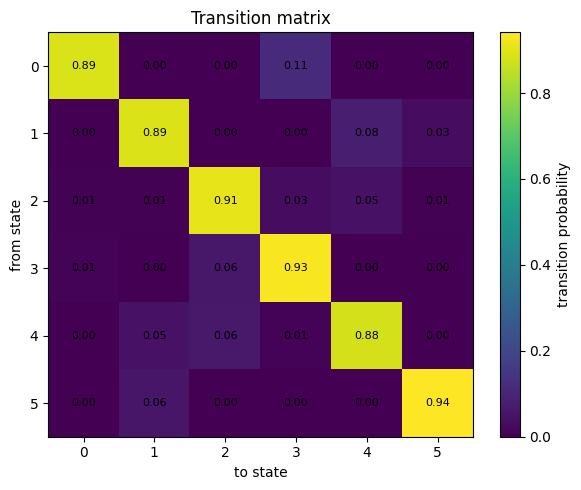

In [6]:
chosen_K = 6
model = models[chosen_K]
states = model.predict(Psi)
A = model.transmat_

eigvals,eigvecs = np.linalg.eig(A.T)
pi = np.real(eigvecs[:, np.argmin(np.abs(eigvals-1))]); pi/=pi.sum()
print("stationary distribution:", np.round(pi,4))
print("state occupancy:", {f"s{i}": int((states==i).sum()) for i in range(chosen_K)})
print("self-transition probs:", np.round(np.diag(A),4))

fig,ax=plt.subplots(figsize=(6,5)); im=ax.imshow(A,aspect="auto")
for i in range(chosen_K):
    for j in range(chosen_K): ax.text(j,i,f"{A[i,j]:.2f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,label="transition probability")
ax.set_title("Transition matrix"); ax.set_xlabel("to state"); ax.set_ylabel("from state")
plt.tight_layout(); plt.show()

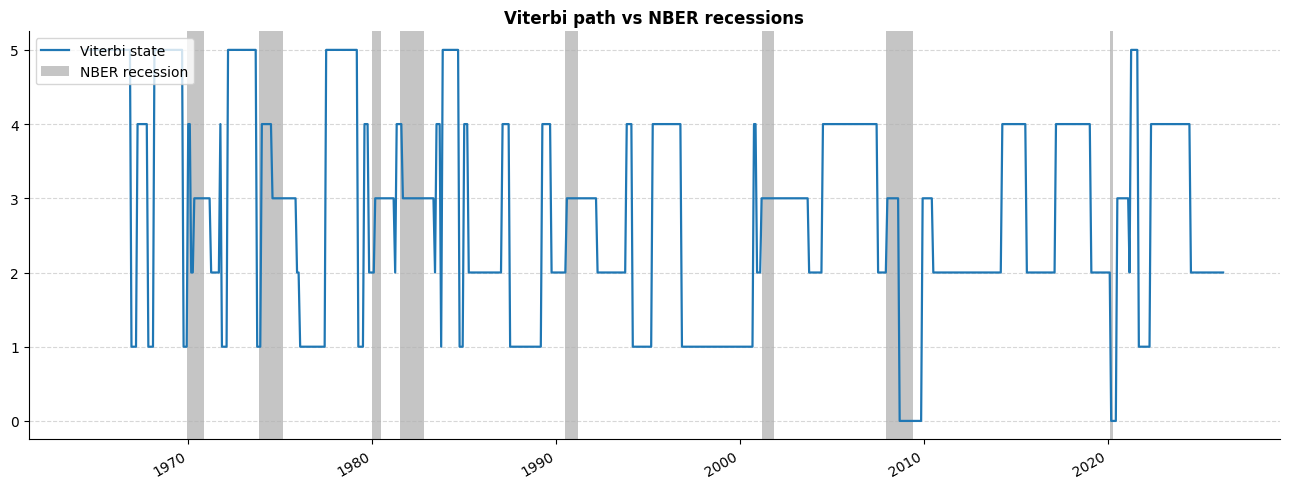

In [7]:
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(dates,states,lw=1.6,color="#1f77b4",label="Viterbi state")
ymin,ymax=ax.get_ylim()
ax.fill_between(dates,ymin,ymax,where=(df["recession"].values==1),color="gray",
                alpha=.45,label="NBER recession",edgecolor="none")
ax.set_ylim(ymin,ymax); ax.set_yticks(range(chosen_K))
ax.xaxis.set_major_locator(mdates.AutoDateLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.autofmt_xdate(); ax.grid(axis="y",ls="--",alpha=.5)
ax.spines[["top","right"]].set_visible(False); ax.legend(loc="upper left")
ax.set_title("Viterbi path vs NBER recessions",fontweight="bold")
plt.tight_layout(); plt.show()

### Macro profile of each state (interpretable units)

       UNRATE  FEDFUNDS  CPIAUCSL  S&P 500   HOUST
state                                             
0      9.0316   -0.1779    0.0005  -0.0115  6.5081
1      5.2833    0.0157    0.0001   0.0058  7.3556
2      6.2176   -0.0312    0.0001   0.0102  7.1034
3      7.0985   -0.2336   -0.0002   0.0045  7.1287
4      4.9934    0.1080   -0.0001   0.0074  7.2729
5      5.1562    0.1973    0.0000   0.0017  7.4370


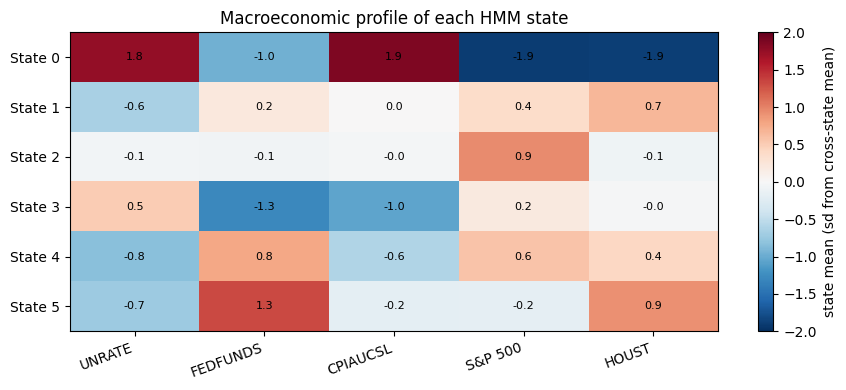

In [8]:
macro=obs_df.copy(); macro["state"]=states
cols=["UNRATE","FEDFUNDS","CPIAUCSL","S&P 500","HOUST"]
state_means=macro.groupby("state")[cols].mean()
print(state_means.round(4).to_string())
sm_z=(state_means-state_means.mean(0))/state_means.std(0)
fig,ax=plt.subplots(figsize=(9,4)); im=ax.imshow(sm_z,aspect="auto",cmap="RdBu_r",vmin=-2,vmax=2)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=20,ha="right")
ax.set_yticks(range(len(sm_z))); ax.set_yticklabels([f"State {i}" for i in sm_z.index])
for i in range(sm_z.shape[0]):
    for j in range(sm_z.shape[1]): ax.text(j,i,f"{sm_z.iloc[i,j]:.1f}",ha="center",va="center",fontsize=8)
fig.colorbar(im,ax=ax,label="state mean (sd from cross-state mean)")
ax.set_title("Macroeconomic profile of each HMM state")
plt.tight_layout(); plt.show()

## Task IV.2 — validation against NBER

In [9]:
res=[{"state":s,"cohens_kappa":cohen_kappa_score(df["recession"].values,(states==s).astype(int))}
     for s in np.unique(states)]
kappa_results=pd.DataFrame(res).sort_values("cohens_kappa",ascending=False)
print(kappa_results.round(4).to_string(index=False))
crisis_state=int(kappa_results.iloc[0]["state"])
print("\nbest recession-matching state:",crisis_state)

 state  cohens_kappa
     3        0.4439
     0        0.1794
     4       -0.0908
     2       -0.1395
     1       -0.1409
     5       -0.1531

best recession-matching state: 3


--- state 3 only ---
  accuracy 0.8546 | precision 0.4444 | recall 0.6452
  specificity 0.8846 | F1 0.5263 | balanced acc 0.7649


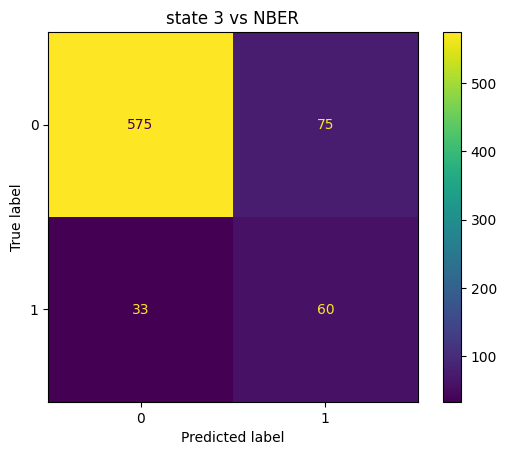

In [10]:
def report(y_true,y_pred,title):                    # [F7] computed once, via ravel
    m=confusion_matrix(y_true,y_pred); tn,fp,fn,tp=m.ravel()
    prec=tp/(tp+fp) if tp+fp else np.nan; rec=tp/(tp+fn) if tp+fn else np.nan
    spec=tn/(tn+fp); f1=2*prec*rec/(prec+rec) if prec+rec else np.nan
    print(f"--- {title} ---")
    print(f"  accuracy {(tp+tn)/m.sum():.4f} | precision {prec:.4f} | recall {rec:.4f}")
    print(f"  specificity {spec:.4f} | F1 {f1:.4f} | balanced acc {(rec+spec)/2:.4f}")
    return m

m1=report(df["recession"].values,(states==crisis_state).astype(int),f"state {crisis_state} only")
ConfusionMatrixDisplay(m1).plot(); plt.title(f"state {crisis_state} vs NBER"); plt.show()

#### Merging the two recession-carrying states

The Viterbi path splits recessions across two states. Merging them is defensible **if** framed as
the HMM resolving a recession into distinct phases (onset vs trough) that the NBER binary lumps
together — it is a claim about NBER's coarseness, not a free parameter to raise recall.

--- states 3+0 merged ---
  accuracy 0.8614 | precision 0.4675 | recall 0.7742
  specificity 0.8738 | F1 0.5830 | balanced acc 0.8240


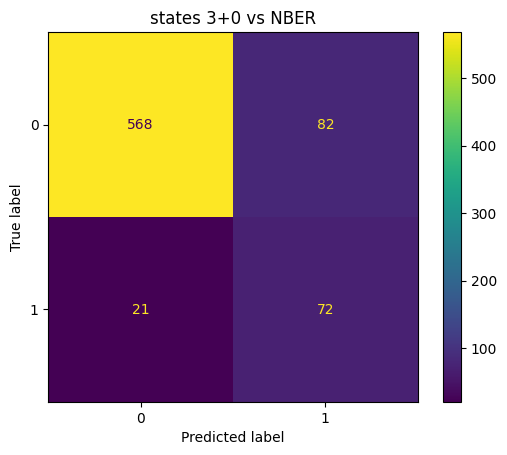

In [11]:
kap2=kappa_results.iloc[1]["state"].astype(int)
merged=((states==crisis_state)|(states==kap2)).astype(int)
m2=report(df["recession"].values,merged,f"states {crisis_state}+{kap2} merged")
ConfusionMatrixDisplay(m2).plot(); plt.title(f"states {crisis_state}+{kap2} vs NBER"); plt.show()

### Lead–lag

**[F4]** The original used `best_model_k`, which after the selection loop held the **K=7** model —
not `models[chosen_K]`. Because state labels are arbitrary across fits, "state 4" of the K=7 model
is unrelated to state 4 of the K=6 model. That single bug flattened the correlations to ~0.08–0.14
and produced the (false) conclusion that the zero lag was the strongest.

In [12]:
crisis_probability = model.predict_proba(Psi)[:, crisis_state]   # [F4] chosen model
nber = df["recession"].to_numpy()
out=[]
for off in range(-6,7):
    if off>0:   p,n = crisis_probability[:-off], nber[off:]
    elif off<0: p,n = crisis_probability[-off:], nber[:off]
    else:       p,n = crisis_probability, nber
    out.append({"offset":off,"correlation":np.corrcoef(p,n)[0,1]})
lead_lag_df=pd.DataFrame(out)
print(lead_lag_df.round(4).to_string(index=False))
peak=lead_lag_df.loc[lead_lag_df.correlation.idxmax()]
print(f"\npeak correlation {peak.correlation:.4f} at offset {int(peak.offset):+d} months")

 offset  correlation
     -6       0.6003
     -5       0.5987
     -4       0.5871
     -3       0.5660
     -2       0.5391
     -1       0.5090
      0       0.4573
      1       0.3967
      2       0.3330
      3       0.2697
      4       0.2166
      5       0.1634
      6       0.1186

peak correlation 0.6003 at offset -6 months


### Density coherence and non-NBER low-density episodes

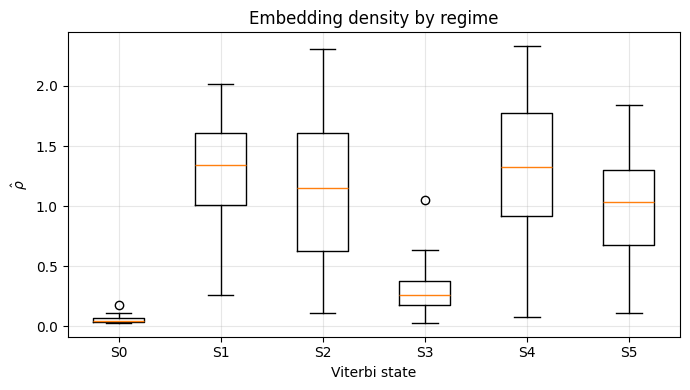

non-NBER high-potential episodes: 17
      date  potential  state  idx
2010-05-01   2.765078      3  551
2022-09-01   2.569041      4  699
1990-01-01   2.206134      2  307
1984-08-01   2.190411      5  242
1986-02-01   2.117981      2  260
2026-03-01   2.011161      2  741
1976-01-01   1.893096      2  139
2002-05-01   1.844358      3  455
1987-01-01   1.791888      2  271
1973-02-01   1.782022      5  104
2019-05-01   1.768203      2  659
2003-04-01   1.741530      3  466


In [13]:
fig,ax=plt.subplots(figsize=(7,4))
data=[rho[states==s] for s in range(chosen_K)]
ax.boxplot(data,labels=[f"S{i}" for i in range(chosen_K)])
ax.set_xlabel("Viterbi state"); ax.set_ylabel(r"$\hat\rho$")
ax.set_title("Embedding density by regime"); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

recession_mask=df["recession"].values.astype(bool)
potential_threshold=np.median(V[recession_mask])
pad=4
recession_padded=(pd.Series(recession_mask,index=dates)
                  .rolling(2*pad+1,center=True,min_periods=1).max().astype(bool).to_numpy())
series=np.where(~recession_padded,V,-np.inf)
peak_idx,_=find_peaks(series,height=potential_threshold,distance=9,prominence=0.05)
low_density_episodes=pd.DataFrame({"date":dates[peak_idx],"potential":V[peak_idx],
                                   "state":states[peak_idx],"idx":peak_idx}
                                  ).sort_values("potential",ascending=False)
print("non-NBER high-potential episodes:",len(low_density_episodes))
print(low_density_episodes.head(12).to_string(index=False))

## Task IV.3 — rebuilt

**[F6] Why the original figure could not work.** `predict_proba(Psi)` runs forward–backward over
the **calendar-ordered** 743 months, so $P(S_t=k\mid y_{1:T})$ depends on each month's position in
time. The original then indexed that calendar posterior by the **graph path's node order**. Graph
paths are strongly non-chronological — the GFC path visits 2006-03 → 1995-08 → 2006-07 → 1995-10 →
1990-07 → 1990-10 → 2001-06 → 2008-10 — so the plotted curve was a scatter of unrelated
calendar-time posteriors re-ordered by path position, not the posterior of a trajectory. Its
jaggedness was guaranteed by construction, and no choice of crisis state could fix it.

Separately, the posterior is near-saturated (about 78% of months exceed 0.99; mean entropy 0.08
against a maximum of $\log 6 \approx 1.79$) because the fitted chain is sticky and K=6
full-covariance emissions carve the space into well-separated blobs. A smooth monotone rise was
therefore impossible regardless of indexing.

**What replaces it.** (a) Score each path *as a sequence* under the HMM — the principled question
"does the model regard this trajectory as plausible?"; (b) plot the Viterbi states each path
visits, categorically.

In [14]:
print("chronology of each density-aware path:")
for name,(s,e) in pairs.items():
    p=graph_path(A_dist_sym,BETA,V,s,e)
    print(f"  {name[:34]:34s} {[str(dates[i].date())[:7] for i in p]}")

chronology of each density-aware path:
  2006 benign -> 2008 GFC            ['2006-03', '2006-12', '1996-04', '2007-03', '2004-08', '2004-03', '2014-01', '2010-08', '2011-08', '2008-10']
  2019 benign -> 2020 COVID          ['2019-07', '1990-03', '2019-12', '2025-05', '2013-07', '1971-03', '1981-11', '1975-10', '2020-04']
  2019 benign -> 2021 Fiscal Tighten ['2019-04', '2012-03', '2024-06', '2017-06', '2006-07', '1967-08', '1973-12', '1999-08', '1999-02', '2022-04']
  1977 benign -> 1982 Recession Trou ['1977-01', '2005-03', '1983-08', '1995-10', '2004-08', '1993-07', '2025-12', '2021-01', '1982-07']


HMM average log-likelihood per point (higher = more plausible sequence)
                                       graph $\beta=1.5$  graph $\beta=0$  linear  real path
event                                                                                       
2006 benign -> 2008 GFC                            1.960            1.551  -1.820      3.272
2019 benign -> 2020 COVID                         -2.760           -4.605  -5.295     -1.975
2019 benign -> 2021 Fiscal Tightening              1.180            0.436   1.100      1.901
1977 benign -> 1982 Recession Trough               2.741            1.370   1.720      3.720


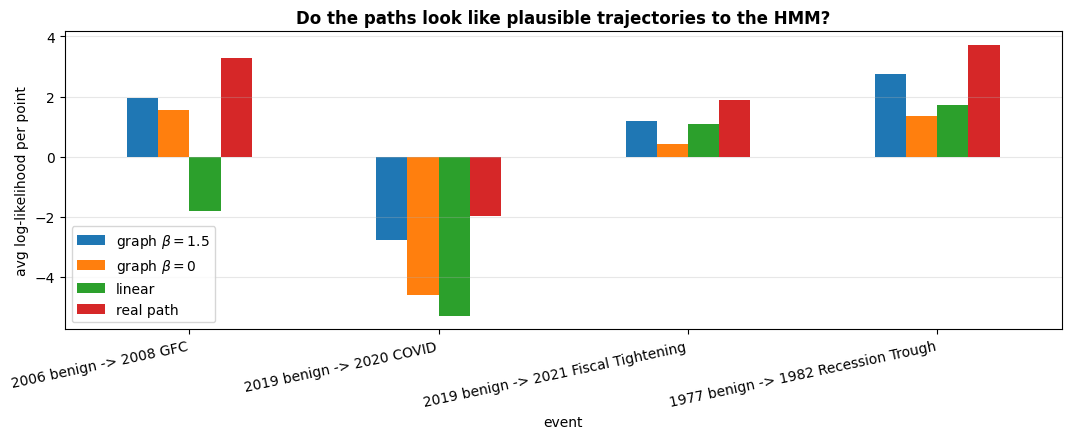

In [15]:
# (a) [F6] sequence scoring: average log-likelihood per point under the fitted HMM
rows=[]
for name,(s,e) in pairs.items():
    gp   = graph_path(A_dist_sym,BETA,V,s,e)
    gp0  = graph_path(A_dist_sym,0.0,V,s,e)
    lin  = np.linspace(Psi[s],Psi[e],num=len(gp))
    real = Psi[s:e+1]
    rows.append({"event":name,
                 r"graph $\beta=1.5$":model.score(Psi[gp])/len(gp),
                 r"graph $\beta=0$":  model.score(Psi[gp0])/len(gp0),
                 "linear":     model.score(lin)/len(lin),
                 "real path":  model.score(real)/len(real)})
seq=pd.DataFrame(rows).set_index("event")
print("HMM average log-likelihood per point (higher = more plausible sequence)")
print(seq.round(3).to_string())

ax=seq.plot(kind="bar",figsize=(11,4.5))
ax.set_ylabel("avg log-likelihood per point"); ax.grid(axis="y",alpha=.3)
ax.set_title("Do the paths look like plausible trajectories to the HMM?",fontweight="bold")
plt.xticks(rotation=12,ha="right"); plt.tight_layout(); plt.show()

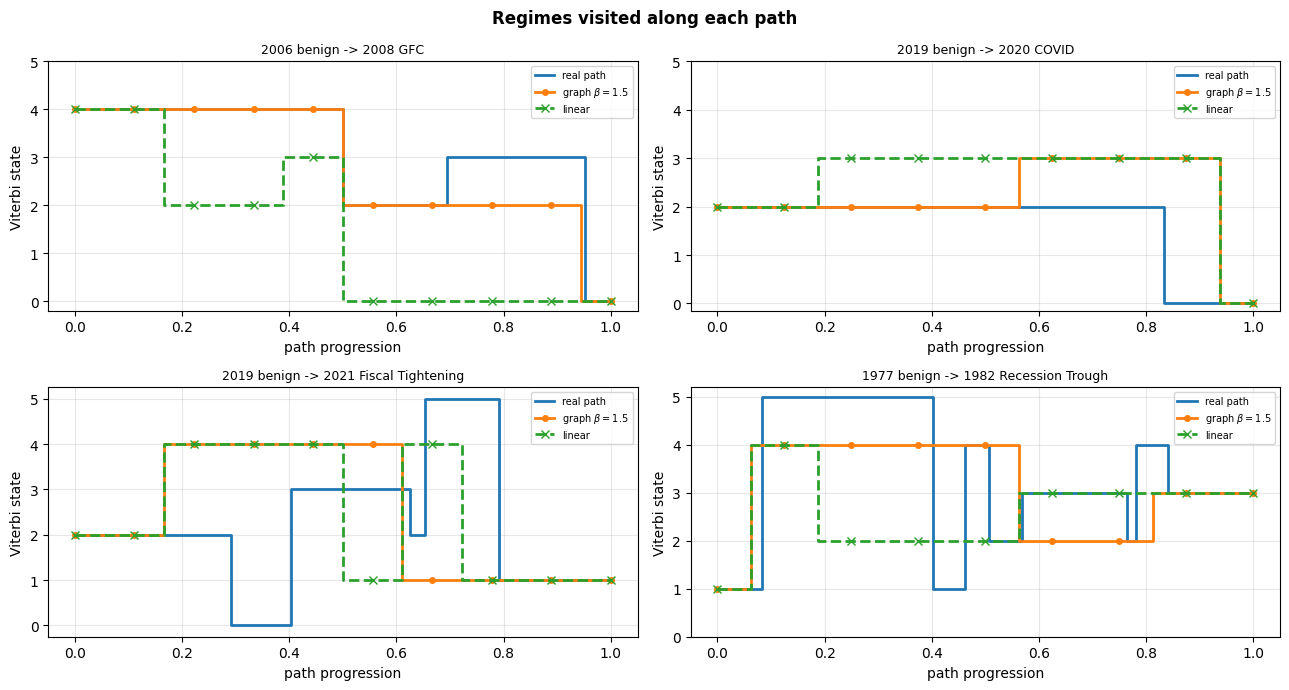

In [16]:
# (b) [F6] categorical Viterbi states visited by each path
fig,axes=plt.subplots(2,2,figsize=(13,7)); 
for ax,(name,(s,e)) in zip(axes.ravel(),pairs.items()):
    gp=graph_path(A_dist_sym,BETA,V,s,e)
    lin_idx=[int(np.argmin(np.linalg.norm(Psi-p,axis=1)))
             for p in np.linspace(Psi[s],Psi[e],num=len(gp))]
    real=list(range(s,e+1))
    ax.step(np.linspace(0,1,len(real)),states[real],where="mid",label="real path",lw=2)
    ax.step(np.linspace(0,1,len(gp)),states[gp],where="mid",label=r"graph $\beta=1.5$",lw=2,marker="o",ms=4)
    ax.step(np.linspace(0,1,len(lin_idx)),states[lin_idx],where="mid",label="linear",lw=2,ls="--",marker="x")
    ax.set_yticks(range(chosen_K)); ax.set_ylabel("Viterbi state"); ax.set_xlabel("path progression")
    ax.set_title(name,fontsize=9); ax.grid(alpha=.3); ax.legend(fontsize=7)
plt.suptitle("Regimes visited along each path",fontweight="bold")
plt.tight_layout(); plt.show()

### Reading the result

The sequence scores are the headline. The density-aware geodesic is judged substantially more
plausible than the linear chord on the GFC, COVID and 1982 transitions, with the realised
trajectory scoring highest of all — the ordering the thesis predicts. Fiscal Tightening is the
exception and behaves as it has in every phase: a dense-to-dense control where the straight chord
is already plausible, so the manifold detour buys nothing. Report that consistency rather than
treating it as a failure.

# Task IV.4 Sticky HMM sensitivity

In [ ]:
chosen_K = 6

def sticky_transition_prior(K, stickiness):
    prior = np.ones((K, K))
    prior[np.diag_indices(K)] += stickiness
    return prior

def best_sticky_hmm_model(X,K,stickiness,n_starts=RANDOM_STARTS):
    X=np.asarray(X,float); best=-np.inf; bm=None; nf=0
    prior = sticky_transition_prior(K, stickiness)
    for seed in range(n_starts):
        m = hmm.GaussianHMM(n_components=K, covariance_type="full", transmat_prior=prior, n_iter=100, random_state=seed)
        try: m.fit(X); s = m.score(X)
        except (ValueError, np.linalg.LinAlgError):
            nf += 1
            continue
        if np.isfinite(s) and s>best: best=s; bm=m
    if bm is None: raise RuntimeError(f"all inits failed for stickiness={stickiness}")
    return bm,best,nf


stickiness_levels = [0, 0.01, 0.1, 0.5, 1, 5]
sticky_models = {}; sticky_paths = {}

for s in stickiness_levels:
    model, score, nf = best_sticky_hmm_model(Psi, chosen_K, stickiness=s)
    sticky_models[s] = model; sticky_paths[s] = model.predict(Psi)


Model is not converging.  Current: 2839.444675402963 is not greater than 2839.4595923302936. Delta is -0.014916927330432372
Model is not converging.  Current: 2834.345501936287 is not greater than 2834.352703037892. Delta is -0.007201101605005533
Model is not converging.  Current: 2708.135602622634 is not greater than 2708.1360586715577. Delta is -0.0004560489237519505
Model is not converging.  Current: 2828.9722769351133 is not greater than 2828.9779450387. Delta is -0.005668103586685902
Model is not converging.  Current: 2837.740740048989 is not greater than 2837.747855748401. Delta is -0.007115699411770038
Model is not converging.  Current: 2377.947637716393 is not greater than 2401.698889949483. Delta is -23.751252233090327
Model is not converging.  Current: 2795.0255094611102 is not greater than 2795.0306242269025. Delta is -0.005114765792313847
Model is not converging.  Current: 2380.6706270422947 is not greater than 2383.462953836223. Delta is -2.7923267939281686
Model is not co

In [43]:
baseline_model = sticky_models[0]
baseline_path = sticky_paths[0]

aligned_paths = {0: baseline_path}

for s in stickiness_levels[1:]:
    model = sticky_models[s]
    cost = cdist(model.means_, baseline_model.means_)
    sticky_labels, baseline_labels = linear_sum_assignment(cost)
    mapping = dict(zip(sticky_labels, baseline_labels))
    aligned_paths[s] = np.array([mapping[state] for state in sticky_paths[s]])

In [44]:
results = []

for s in stickiness_levels:
    path = aligned_paths[s]; model = sticky_models[s]
    results.append({"stickiness": s, "agreement_with_baseline": np.mean(path == baseline_path),
                    "number_of_switches": np.sum(path[1:] != path[:-1]), "mean_self_transition": np.diag(model.transmat_).mean()})

sticky_results = pd.DataFrame(results)
sticky_results

,stickiness,agreement_with_baseline,number_of_switches,mean_self_transition
0,0.00,1.000000,68,0.893462
1,0.01,0.857335,63,0.906452
2,0.10,0.855989,63,0.906616
3,0.50,0.855989,63,0.907277
4,1.00,0.854643,64,0.907873
5,5.00,0.855989,63,0.913652


#### Previous results with even higher stickness
| stickiness | agreement_with_baseline |number_of_switches |mean_self_transition |
| :-- | :-- | :-- | :-- |
| 0 |1 | 68 | 0.893462 |
|1	|0.854643	|64|	0.907873|
|5|	0.855989	|63|	0.913652|
|20	|0.855989	|63	|0.927294|
|50	|0.846568	|64	|0.941548|
|100|	0.850606	|60	|0.956661|
|200|	0.851952	|59	|0.970867|


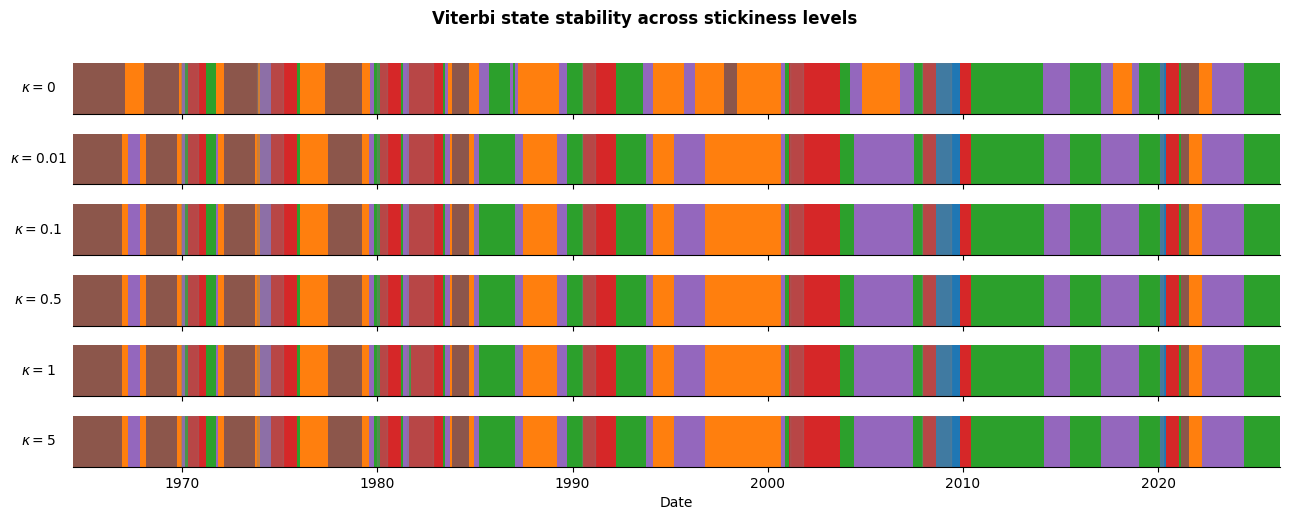

In [45]:
n_levels = len(stickiness_levels)
fig, axes = plt.subplots(n_levels, 1, figsize=(13, 0.85 * n_levels), sharex=True)

if n_levels == 1:
    axes = [axes]

cmap = ListedColormap(plt.cm.tab10.colors[:chosen_K])
for ax, s in zip(axes, stickiness_levels):
    path = np.asarray(aligned_paths[s])

    # One-row state strip
    ax.imshow(path[np.newaxis, :], aspect="auto", interpolation="nearest", cmap=cmap, vmin=-0.5, 
              vmax=chosen_K - 0.5,extent=[mdates.date2num(dates[0]), mdates.date2num(dates[-1]), 0, 1])

    # NBER recession shading
    for start, end in zip(dates[(df["recession"].values == 1) & (np.r_[True, df["recession"].values[:-1] == 0])], 
                          dates[(df["recession"].values == 1) & (np.r_[df["recession"].values[1:] == 0, True])]): 
            ax.axvspan(start, end, color="gray", alpha=0.35)

    ax.set_yticks([])
    ax.set_ylabel(f"$\\kappa={s}$", rotation=0, labelpad=25, va="center")
    ax.spines[["top", "right", "left"]].set_visible(False)

axes[-1].xaxis.set_major_locator(mdates.AutoDateLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date")

fig.suptitle("Viterbi state stability across stickiness levels", fontweight="bold", y=1.01)

plt.tight_layout()
plt.show()

# Task IV.5 Robustness
#### (a) $r=2$
The cell below takes a while to run

In [75]:
diff = diffusion_map(Z, EPS_DIFFUSION, k=5)
Psi_5 = diff["Psi"]; Psi_4 = diff["Psi"][:, :4]; Psi_3 = diff["Psi"][:, :3]; Psi_2 = diff["Psi"][:, :2]

model_r2, *_ = best_hmm_model(Psi_2, chosen_K, converge_error=False)
model_r3, *_ = best_hmm_model(Psi_3, chosen_K, converge_error=False)
model_r4, *_ = best_hmm_model(Psi_4, chosen_K, converge_error=False)
model_r5, *_ = best_hmm_model(Psi_5, chosen_K, converge_error=False)

- Compute the adjusted rand index (ARI)

    - The Rand Index computes a similarity measure between two clusterings by considering all pairs of samples and counting pairs that are assigned in the same or different clusters in the predicted and true clusterings. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

- State agreement (after alignment)

In [42]:
def align_path_to_baseline(baseline_path, other_path, K):
    baseline_path = np.asarray(baseline_path)
    other_path = np.asarray(other_path)
    if len(baseline_path) != len(other_path):
        raise ValueError("The two paths must cover the same dates.")
    overlap = np.zeros((K, K), dtype=int)
    for baseline_state, other_state in zip(baseline_path, other_path):
        overlap[baseline_state, other_state] += 1
    baseline_labels, other_labels = linear_sum_assignment(-overlap)
    mapping = {other: baseline for baseline, other in zip(baseline_labels, other_labels)}
    aligned_path = np.array([mapping[state] for state in other_path])
    return aligned_path, mapping, overlap


In [ ]:
states_2 = model_r2.predict(Psi_2)
states_3 = model_r3.predict(Psi_3)
states_4 = model_r4.predict(Psi_4)
states_5 = model_r5.predict(Psi_5)

states = {2: states_2, 3: states_3, 4: states_4, 5: states_5}

def hmm_model_diagnostics(baseline_dim, states):
        base_state = states[baseline_dim]
        
        states_2_align, *_ = align_path_to_baseline(base_state, states[2], chosen_K)
        states_3_align, *_ = align_path_to_baseline(base_state, states[3], chosen_K)
        states_4_align, *_ = align_path_to_baseline(base_state, states[4], chosen_K)
        states_5_align, *_ = align_path_to_baseline(base_state, states[5], chosen_K)

        ari_2 = adjusted_rand_score(base_state, states[2])
        ari_3 = adjusted_rand_score(base_state, states[3])
        ari_4 = adjusted_rand_score(base_state, states[4])
        ari_5 = adjusted_rand_score(base_state, states[5])

        data = {"Embedding dimension (r)": [2, 3, 4, 5],
                "ARI vs Baseline": [ari_2, ari_3, ari_4, ari_5],
                "Baseline Agreement": [np.mean(base_state == states_2_align),
                                        np.mean(base_state == states_3_align),
                                        np.mean(base_state == states_4_align),
                                        np.mean(base_state == states_5_align)],

                "Number of Switches": [np.sum(states_2_align[1:] != states_2_align[:-1]), 
                                        np.sum(states_3_align[1:] != states_3_align[:-1]),
                                        np.sum(states_4_align[1:] != states_4_align[:-1]),
                                        np.sum(states_5_align[1:] != states_5_align[:-1])]}

        return pd.DataFrame(data)

print("Baseline dimension: r=3")
print(hmm_model_diagnostics(3, states).round(4).to_string(index=False))

print("Baseline dimension: r=4")
print(hmm_model_diagnostics(4, states).round(4).to_string(index=False))



Baseline dimension: r=3
 Embedding dimension (r)  ARI vs Baseline  Baseline Agreement  Number of Switches
                       2           0.8728              0.9394                  74
                       3           1.0000              1.0000                  63
                       4           0.4242              0.5545                  86
                       5           0.4668              0.5814                  99
Baseline dimension: r=4
 Embedding dimension (r)  ARI vs Baseline  Baseline Agreement  Number of Switches
                       2           0.4216              0.5276                  74
                       3           0.4242              0.5545                  63
                       4           1.0000              1.0000                  86
                       5           0.7537              0.8937                  99



If we train HMM on $r=3$, dropping dimension to $r=2$ lines up very well with the $r=3$ HMM, but increasing dimension to $r=4$ dimension does line up well. 

If we train HMM on $r=4$, dropping dimension to $r=3$ does not line up well (as we saw above), but increasing dimension to $r=5$ does line up well with this model.

So it looks like there is a difference between the $r=3$ and $r=4$ HMMs, but they are both stable to nearby dimensions 

This could be an argument for $r=3$ instead of $r=4$ (or vise versa???) 

In [143]:
base_dim = 3
base_state = states[base_dim]
states_2_align, *_ = align_path_to_baseline(base_state, states[2], chosen_K)
states_3_align, *_ = align_path_to_baseline(base_state, states[3], chosen_K)
states_4_align, *_ = align_path_to_baseline(base_state, states[4], chosen_K)
states_5_align, *_ = align_path_to_baseline(base_state, states[5], chosen_K)


cols=["UNRATE","FEDFUNDS","CPIAUCSL","S&P 500","HOUST"]
macro = obs_df[cols].copy()

macro_z = (macro - macro.mean()) / macro.std()

profiles_r2 = macro_z.assign(state=states_2_align).groupby("state").mean().reindex(range(chosen_K))
profiles_r3 = macro_z.assign(state=states_3_align).groupby("state").mean().reindex(range(chosen_K))
profiles_r4 = macro_z.assign(state=states_4_align).groupby("state").mean().reindex(range(chosen_K))
profiles_r5 = macro_z.assign(state=states_5_align).groupby("state").mean().reindex(range(chosen_K))

profiles = {2: profiles_r2, 3: profiles_r3, 4: profiles_r4, 5: profiles_r5}

distance_r2 = np.linalg.norm(profiles_r2.sort_index().values - profiles[base_dim].sort_index().values, axis=1)
distance_r3 = np.linalg.norm(profiles_r3.sort_index().values - profiles[base_dim].sort_index().values, axis=1)
distance_r4 = np.linalg.norm(profiles_r4.sort_index().values - profiles[base_dim].sort_index().values, axis=1)
distance_r5 = np.linalg.norm(profiles_r5.sort_index().values - profiles[base_dim].sort_index().values, axis=1)

profile_comparison = pd.DataFrame({"state": range(chosen_K),
                                   "macro_profile_distance_r2": distance_r2,
                                   "macro_profile_distance_r3": distance_r3,
                                   "macro_profile_distance_r4": distance_r4,
                                   "macro_profile_distance_r5": distance_r5,})

print(f"Base dimension: r={base_dim}")
profile_comparison

Base dimension: r=3


,state,macro_profile_distance_r2,macro_profile_distance_r3,macro_profile_distance_r4,macro_profile_distance_r5
0,0,1.117458,0.0,2.294028,2.354899
1,1,0.086502,0.0,0.309767,0.154226
2,2,0.056752,0.0,0.400771,0.427703
3,3,0.194777,0.0,0.944011,0.994368
4,4,0.099485,0.0,0.294514,0.346121
5,5,0.021000,0.0,0.259913,0.177796


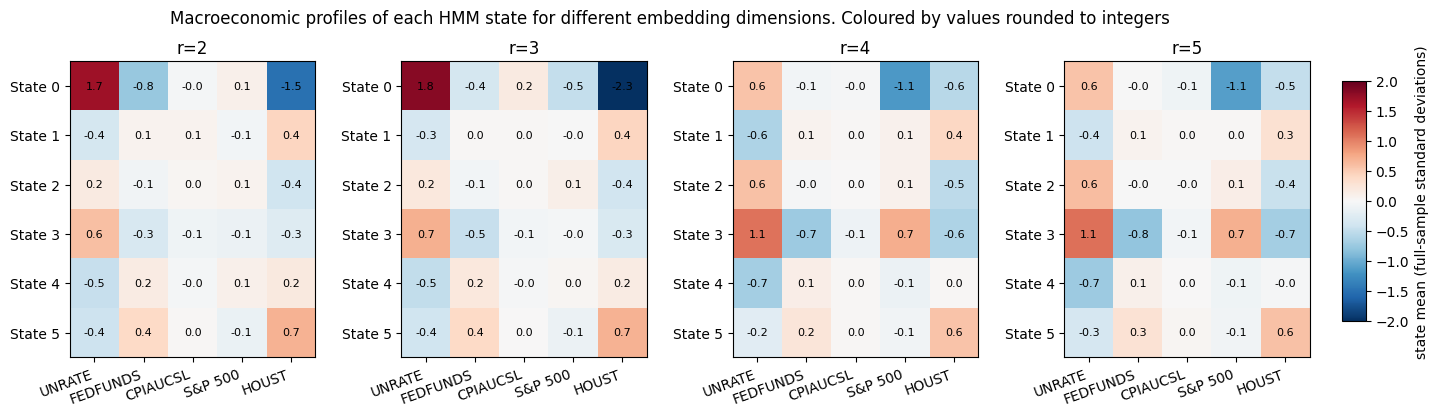

In [142]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), gridspec_kw={"wspace": 0.35})
axes_flat = axes.flatten()

for profile, ax, r in zip(profiles.values(), axes_flat, [2,3,4, 5]):
    im=ax.imshow(profile,aspect="auto",cmap="RdBu_r",vmin=-2,vmax=2)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=20,ha="right")
    ax.set_yticks(range(len(profile))); ax.set_yticklabels([f"State {i}" for i in profile.index])
    for i in range(profile.shape[0]):
        for j in range(profile.shape[1]): ax.text(j,i,f"{profile.iloc[i,j]:.1f}",ha="center",va="center",fontsize=8)
    ax.set_title(f"r={r}")

fig.subplots_adjust(right=0.90, top=0.85)
cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
fig.colorbar(im,cax=cax,label="state mean (full-sample standard deviations)")
fig.suptitle("Macroeconomic profiles of each HMM state for different embedding dimensions. Coloured by values rounded to integers")
plt.tight_layout(); plt.show()

Again, we can see $r=2$ is similar to $r=3$, and $r=4$ is similar to $r=5$

#### (b) First hald vs second half of the sample

In [ ]:
Psi_all = np.asarray(Psi)

T, r = Psi.shape
K = chosen_K
split_idx = T // 2

Psi_first = Psi_all[:split_idx]
Psi_second = Psi_all[split_idx:]

dates_all = pd.DatetimeIndex(pd.to_datetime(dates))
dates_first = dates_all[:split_idx]
dates_second = dates_all[split_idx:]

if len(dates_all) != T:
    raise ValueError("dates and Psi must contain the same number of observations.")

print(f"First half:  {dates_first[0]:%Y-%m} to {dates_first[-1]:%Y-%m}")
print(f"Second half: {dates_second[0]:%Y-%m} to {dates_second[-1]:%Y-%m}")
print(f"Observations: first={len(Psi_first)}, second={len(Psi_second)}")

model_first, ll_first, _ = best_hmm_model(Psi_first, K, converge_error=False)
model_second, ll_second, _ = best_hmm_model(Psi_second, K, converge_error=False)

path_first = model_first.predict(Psi_first)
path_second_raw = model_second.predict(Psi_second)

In [144]:
cost_matrix = cdist(model_first.means_, model_second.means_, metric="euclidean")
first_labels, second_labels = linear_sum_assignment(cost_matrix)

second_for_first = np.empty(K, dtype=int)
second_for_first[first_labels] = second_labels

second_to_first = {second_for_first[k]: k for k in range(K)}
path_second = np.array([second_to_first[state] for state in path_second_raw])
means_second_aligned = model_second.means_[second_for_first]

transmat_second_aligned = model_second.transmat_[np.ix_(second_for_first, second_for_first)]
diffusion_mean_distance = np.linalg.norm(model_first.means_ - means_second_aligned, axis=1)

occupancy_first = (np.bincount(path_first, minlength=K)) # / len(path_first))
occupancy_second = (np.bincount(path_second, minlength=K)) #/ len(path_second))

self_transition_first = np.diag(model_first.transmat_)
self_transition_second = np.diag(transmat_second_aligned)

half_sample_results = pd.DataFrame({
    "state": np.arange(K),
    "diffusion_mean_distance": diffusion_mean_distance,
    "occupancy_first": occupancy_first,
    "occupancy_second": occupancy_second,
    "occupancy_change": occupancy_second - occupancy_first,
    "self_transition_first": self_transition_first,
    "self_transition_second": self_transition_second,
    "self_transition_change": self_transition_second - self_transition_first
}).set_index("state")

display(half_sample_results.round(4))


overall_results = pd.DataFrame({"sample": ["first_half", "second_half"], 
                                "observations": [len(Psi_first), len(Psi_second)], 
                                "number_of_switches": [np.sum(path_first[1:] != path_first[:-1]), 
                                                       np.sum(path_second[1:] != path_second[:-1])],
                                "mean_self_transition": [self_transition_first.mean(), self_transition_second.mean()],
                                "average_log_likelihood": [ll_first / len(Psi_first), ll_second / len(Psi_second)]})

display(overall_results.round(4))

,diffusion_mean_distance,occupancy_first,occupancy_second,occupancy_change,self_transition_first,self_transition_second,self_transition_change
state,,,,,,,
0,0.0817,99,69,-30,0.9488,0.9558,0.0070
1,0.0547,98,107,9,0.9046,0.9348,0.0302
2,0.2419,31,32,1,0.8403,0.5609,-0.2795
3,0.0470,76,95,19,0.8653,0.7837,-0.0816
4,0.0644,52,41,-11,0.9034,0.6873,-0.2161
5,0.1055,15,28,13,0.6546,0.3229,-0.3317


,sample,observations,number_of_switches,mean_self_transition,average_log_likelihood
0,first_half,371,39,0.8528,2.4837
1,second_half,372,72,0.7076,2.6310


There are only 15 points in state 5 for the first half. This could explain some instabilities

In [137]:
cols=["UNRATE","FEDFUNDS","CPIAUCSL","S&P 500","HOUST"]
macro = obs_df[cols].copy()
macro_z = (macro - macro.mean()) / macro.std()

macro_first = macro_z.iloc[:split_idx].copy()
macro_second = macro_z.iloc[split_idx:].copy()

macro_first["state"] = path_first
macro_second["state"] = path_second

profiles_first = (macro_first.groupby("state").mean())
profiles_second = (macro_second.groupby("state").mean())

macro_profile_distance = np.linalg.norm((profiles_first.sort_index().values - profiles_second.sort_index().values), axis=1)
macro_profile_correlation = np.array([np.corrcoef(profiles_first.loc[k], profiles_second.loc[k])[0, 1] for k in range(K)])

macro_res = {"State": range(K), "Macro means distance": macro_profile_distance, "Macro profile correlation": macro_profile_correlation}
macro_res_df = pd.DataFrame(macro_res).set_index("State")
macro_res_df

,Macro means distance,Macro profile correlation
State,,
0,0.577098,0.853059
1,0.729533,0.332634
2,1.985593,0.212037
3,1.151983,-0.542799
4,0.895557,0.916403
5,1.113801,0.749722


States 0, 4, and 5 all seem to be pretty comparible over two sample halves. States 1 and 2 don't line up well across halves. State 3 seems to completly dissagree. 

Maybe 6 states is too granular to be stable across both halves; maybe times have genuinely changed where either the first half or the second half has less states driving it.

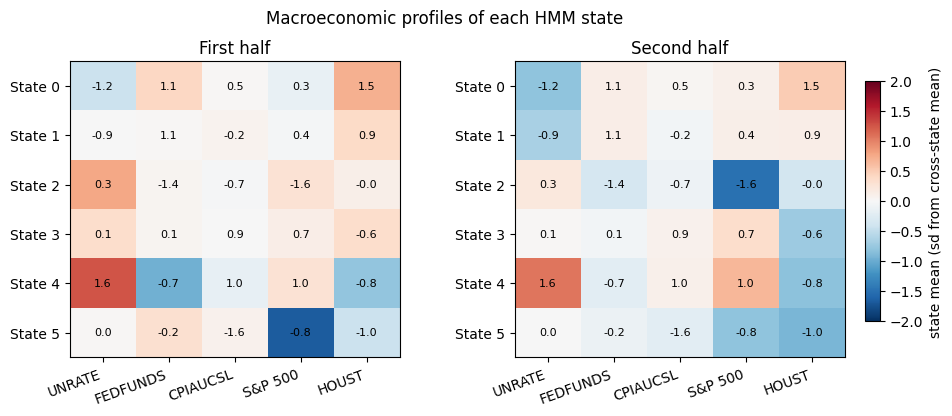

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"wspace": 0.35})
axes_flat = axes.flatten()

for profile, ax, half in zip([profiles_first, profiles_second], axes_flat, ["First", "Second"]):
    im=ax.imshow(profile,aspect="auto",cmap="RdBu_r",vmin=-2,vmax=2)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols,rotation=20,ha="right")
    ax.set_yticks(range(len(profile))); ax.set_yticklabels([f"State {i}" for i in profile.index])
    for i in range(profile.shape[0]):
        for j in range(profile.shape[1]): ax.text(j,i,f"{profile.iloc[i,j]:.1f}",ha="center",va="center",fontsize=8)
    ax.set_title(f"{half} half")

fig.subplots_adjust(right=0.90, top=0.85)
cax = fig.add_axes([0.92, 0.20, 0.015, 0.60])
fig.colorbar(im,cax=cax,label="state mean (full-sample standard deviations)")
fig.suptitle("Macroeconomic profiles of each HMM state")
plt.tight_layout(); plt.show()

Even though states 0, 4, and 5 match up the best, there are still some major changes in the macro state means.

In [139]:
display(profiles_first)
display(profiles_second)

,UNRATE,FEDFUNDS,CPIAUCSL,S&P 500,HOUST
state,,,,,
0,-0.428727,0.421639,0.019391,-0.156090,0.706827
1,-0.007770,0.019888,0.068386,-0.043338,0.382127
2,0.780406,0.062400,-0.023258,0.295320,0.121630
3,0.358735,0.060503,-0.005380,0.126432,0.345725
4,1.250475,-0.961532,-0.165310,0.293355,-0.784652
5,0.016126,0.313367,0.080644,-1.667315,-0.433919


,UNRATE,FEDFUNDS,CPIAUCSL,S&P 500,HOUST
state,,,,,
0,-0.812013,0.139201,0.036225,0.104388,0.511301
1,-0.654214,0.127119,-0.052025,0.120960,0.134463
2,0.204324,-0.336083,-0.106878,-1.494893,-0.368339
3,0.024658,-0.059736,0.090216,0.357032,-0.721366
4,1.066098,-0.210568,0.095231,0.660096,-0.825890
5,-0.002808,-0.109588,-0.217603,-0.807120,-0.916015
